In [1]:
# ============================================================
# [순서 2 | I] 원천 카드 병합 (성별·연령)
# 데이터: 원천 카드(주제1) + 07 기상
# 목적: 07에 없는 성별·연령 정보를 살려서 기상·특보·달력 변수를 붙임
# ============================================================
import pandas as pd

# ── 1. 불러오기 ──
원천 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\빅콘 제공 데이터 셋\신한카드\신한카드_빅콘테스트2026_데이터1.txt', sep='\t',
                   encoding='cp949', dtype={'TA_YMD': str})
기존 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig',
                   dtype={'일자': str}, low_memory=False)

# ── 2. 원천 정리 ──
원천 = 원천.rename(columns={'TA_YMD': '일자', 'TIME_GB': '시간대', 'MCT_SGG_CD': '시군구',
                            'MCT_RY_CD': '카드업종', 'SEX_CCD': '성별', 'AGE_CCD': '연령대',
                            'TS_AT': '결제금액', 'USE_CNT': '결제건수'})
원천['연령대'] = 원천['연령대'].str.replace(' ', '', regex=False)      # '20 대' → '20대'
원천['고객구분'] = (원천['성별'] == '법인').map({True: '법인', False: '개인'})
원천['결제금액'] = pd.to_numeric(원천['결제금액'], errors='coerce')
원천['결제건수'] = pd.to_numeric(원천['결제건수'], errors='coerce')

print('원천 행수:', f'{len(원천):,}')
print('결측 결제금액:', 원천['결제금액'].isna().sum())
print(원천.groupby('고객구분')[['결제금액', '결제건수']].sum().rename_axis('고객구분'))

# ── 3. 07에서 기상·특보·달력 변수만 추출 (시군구 × 일자 × 시간대 1행) ──
결제열 = ['카드업종', '개인_결제금액', '개인_결제건수', '법인_결제금액', '법인_결제건수']
기상_시간대 = 기존.drop(columns=결제열).drop_duplicates(subset=['시군구', '일자', '시간대'])
print('기상 키 중복 여부:', 기상_시간대.duplicated(subset=['시군구', '일자', '시간대']).any())

# ── 4. 병합 ──
병합 = 원천.merge(기상_시간대, on=['시군구', '일자', '시간대'], how='left', indicator=True)

# ── 5. 병합 점검 ──
print('\n[병합 점검]')
print('원천 행수 = 병합 행수:', len(원천) == len(병합))
print(병합['_merge'].value_counts().rename('병합결과'))

# 업종 목록 일치 여부
원천업종, 기존업종 = set(원천['카드업종']), set(기존['카드업종'])
print('원천에만 있는 업종:', 원천업종 - 기존업종)
print('07에만 있는 업종:', 기존업종 - 원천업종)

# 07이 이 원천을 집계한 파일인지 확인 (합계 비교)
비교 = pd.DataFrame({
    '원천': [원천.loc[원천['고객구분'] == '개인', '결제금액'].sum(),
             원천.loc[원천['고객구분'] == '법인', '결제금액'].sum()],
    '07': [기존['개인_결제금액'].sum(), 기존['법인_결제금액'].sum()]},
    index=['개인 결제금액', '법인 결제금액'])
비교['차이'] = 비교['원천'] - 비교['07']
print('\n[07과 합계 비교]')
print(비교.map(lambda x: f'{x:,.0f}'))

# ── 6. 저장 (원본은 그대로 두고 별도 파일로) ──
병합 = 병합.drop(columns='_merge')
병합.to_csv('12_원천카드_성별연령_시간대기상.csv', index=False, encoding='utf-8-sig')
print('\n저장 완료:', 병합.shape)

원천 행수: 1,044,710
결측 결제금액: 0
                결제금액       결제건수
고객구분                           
개인    30151084830915  571960474
법인     5714771826221   40389886
기상 키 중복 여부: False

[병합 점검]
원천 행수 = 병합 행수: True
_merge
both          1044710
left_only           0
right_only          0
Name: 병합결과, dtype: int64
원천에만 있는 업종: set()
07에만 있는 업종: set()

[07과 합계 비교]
                         원천                  07 차이
개인 결제금액  30,151,084,830,915  30,151,084,830,915  0
법인 결제금액   5,714,771,826,221   5,714,771,826,221  0

저장 완료: (1044710, 57)


[상권별 연결된 500m 기상격자 수]
        count  mean  std  min  25%  50%  75%   max
시군구                                               
강원 춘천시   52.0   7.0  9.3  1.0  3.0  4.0  6.0  44.0
서울 강남구   95.0   3.4  2.0  1.0  2.0  3.0  4.0  14.0

[지역별 고유 기상격자 수]
시군구
강원 춘천시    294
서울 강남구    123
Name: 고유 기상격자 수, dtype: int64

기상 결합 안 된 행 수: 0

[지역별 상권 분포 요약]
시군구                                       강원 춘천시  서울 강남구
지표                                  통계                  
평균체감최고                              mean   30.36   30.90
                                    std     0.14    0.36
                                    min    29.61   30.60
                                    max    30.48   32.94
폭염33일 수                             mean   18.21   24.73
                                    std     1.65    7.32
                                    min    12.00   19.00
                                    max    21.00   56.00
폭염35일 수                             mean    6.15    6.19
                                  

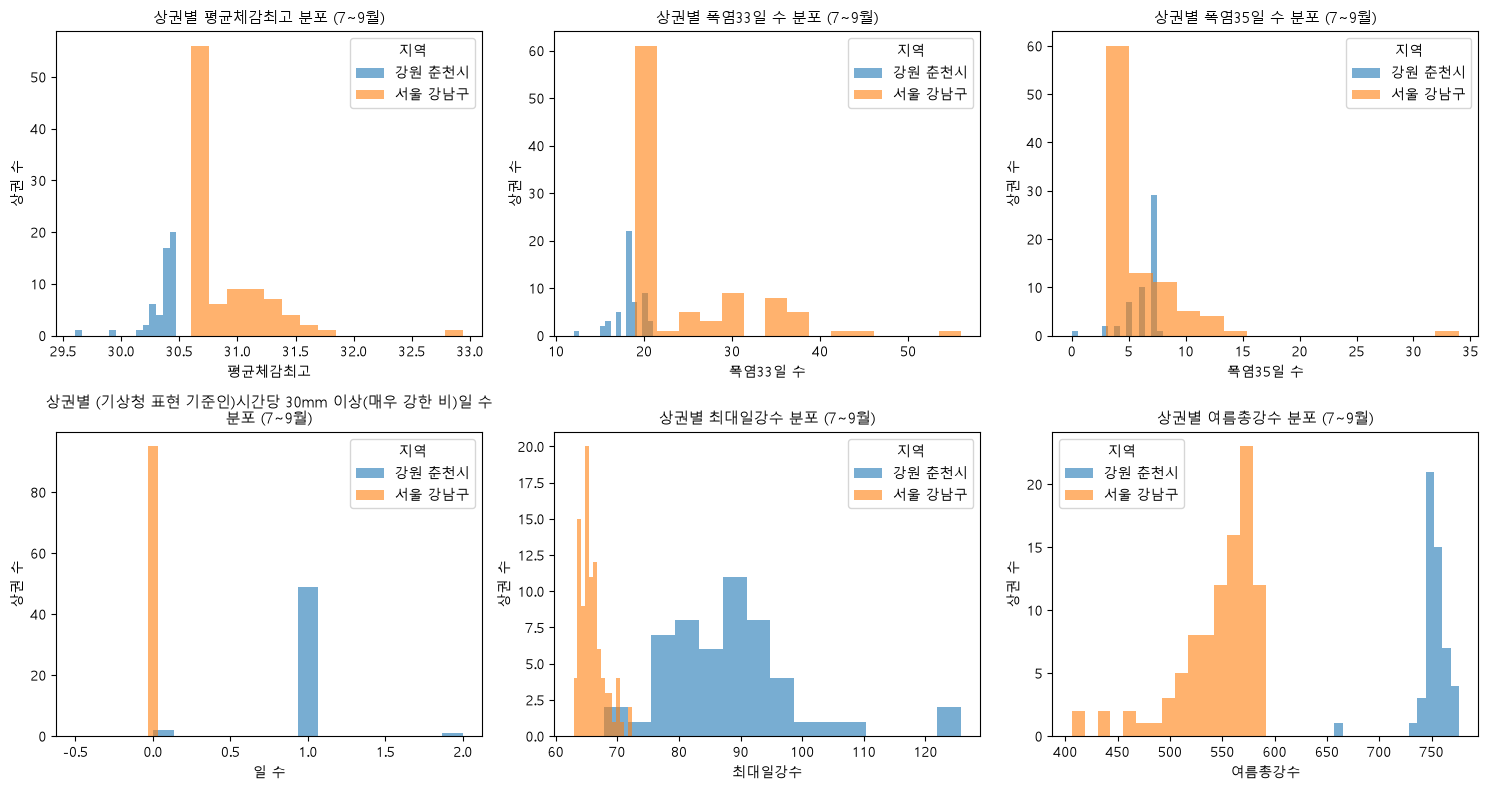

In [2]:
# ============================================================
# [순서 1 | C] 상권 간 위해 차이
# 데이터: 06 + 03
# 목적: 같은 지역 안에서도 상권마다 폭염·호우 강도가 다른지 확인
#       → H를 상권 단위 격자 기상으로 정의할 의미가 있는지 판단
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

기상 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\06_기상_500m_일별 (1).csv', encoding='utf-8-sig', dtype={'일자': str})
격자50 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\03_격자_50m_상권_202506.csv', encoding='utf-8-sig')

기상['일자'] = pd.to_datetime(기상['일자'], format='%Y%m%d')
기상 = 기상[기상['일자'].dt.month.between(7, 9)]      # 폭염·호우가 몰린 여름만

# ── 1. 상권 ↔ 기상격자 가중치 (50m 격자의 점포 수 기준) ──
연결 = (격자50[격자50['상권ID'].notna()]
          .groupby(['상권ID', '시군구', '기상격자ID'])['격자점포수'].sum()
          .reset_index())
연결['가중치'] = 연결['격자점포수'] / 연결.groupby('상권ID')['격자점포수'].transform('sum')

print('[상권별 연결된 500m 기상격자 수]')
print(연결.groupby(['시군구', '상권ID']).size().groupby('시군구').describe().round(1))
print('\n[지역별 고유 기상격자 수]')
print(연결.groupby('시군구')['기상격자ID'].nunique().rename('고유 기상격자 수'))

# ── 2. 상권 × 일 기상 (점포 수 가중평균) ──
사용열 = ['체감온도최고_계산', '일강수합_mm', '시간최대강수_mm', '폭염주의보급_33도', '폭염경보급_35도']
상권일 = 연결.merge(기상[['기상격자ID', '일자'] + 사용열], on='기상격자ID', how='left')
print('\n기상 결합 안 된 행 수:', 상권일['일자'].isna().sum())
for c in 사용열:
    상권일[c] = 상권일[c] * 상권일['가중치']
상권일 = 상권일.groupby(['상권ID', '시군구', '일자'])[사용열].sum(min_count=1).reset_index()

# ── 3. 상권별 여름 위해 요약 ──
상권H = (상권일.groupby(['상권ID', '시군구'])
           .agg(평균체감최고=('체감온도최고_계산', 'mean'),
                폭염33일수=('폭염주의보급_33도', lambda s: (s >= 0.5).sum()),
                폭염35일수=('폭염경보급_35도', lambda s: (s >= 0.5).sum()),
                시간당30mm일수=('시간최대강수_mm', lambda s: (s >= 30).sum()),
                최대일강수=('일강수합_mm', 'max'),
                여름총강수=('일강수합_mm', 'sum'))
           .reset_index())

# 컬럼명(계산용) → 표시 이름(그래프·표용)
지표이름 = {'평균체감최고': '평균체감최고',
           '폭염33일수': '폭염33일 수',
           '폭염35일수': '폭염35일 수',
           '시간당30mm일수': '(기상청 표현 기준인)시간당 30mm 이상(매우 강한 비)일 수',
           '최대일강수': '최대일강수',
           '여름총강수': '여름총강수'}
지표 = list(지표이름.keys())

# ── 4. 지역 안 상권 간 차이 vs 지역 간 차이 ──
지역내 = 상권H.groupby('시군구')[지표].agg(['mean', 'std', 'min', 'max']).T
지역내 = 지역내.rename(index=지표이름, level=0)
지역내.index.names = ['지표', '통계']
print('\n[지역별 상권 분포 요약]')
print(지역내.round(2))

비교 = pd.DataFrame({
    '지역 간 평균 차이': (상권H.groupby('시군구')[지표].mean().diff().iloc[-1]).abs(),
    '강남 상권 간 범위': 상권H[상권H['시군구'] == '서울 강남구'][지표].agg(lambda s: s.max() - s.min()),
    '춘천 상권 간 범위': 상권H[상권H['시군구'] == '강원 춘천시'][지표].agg(lambda s: s.max() - s.min()),
}).rename(index=지표이름)
비교.index.name = '지표'
print('\n[지역 간 차이 vs 지역 안 상권 간 범위]')
print(비교.round(2))

# ── 5. 분포 그림 ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, 지표):
    for 지역, g in 상권H.groupby('시군구'):
        ax.hist(g[c], bins=15, alpha=0.6, label=지역)
    이름 = 지표이름[c]
    제목 = f'상권별 {이름} 분포 (7~9월)'
    if len(제목) > 25:                                  # 긴 제목은 두 줄로
        제목 = f'상권별 {이름}\n분포 (7~9월)'
    ax.set_title(제목, fontsize=11)
    ax.set_xlabel(이름 if len(이름) <= 20 else '일 수')
    ax.set_ylabel('상권 수')
    ax.legend(title='지역')
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# [순서 1 | C-보완] 상권 간 위해 차이 - 강남 이상치 확인
# 데이터: 06 + 03 (앞 셀의 상권H, 연결, 기상 사용)
# 목적: 폭염·총강수 극단값 상권이 실제 값인지, 특정 기상격자 문제인지 확인
# ============================================================

# ── 1. 극단값 상권 목록 ──
강남H = 상권H[상권H['시군구'] == '서울 강남구']
의심 = pd.concat([강남H.nlargest(3, '폭염33일수'), 강남H.nsmallest(3, '여름총강수')]).drop_duplicates('상권ID')
print('[극단값 상권]')
print(의심[['상권ID', '평균체감최고', '폭염33일수', '폭염35일수', '여름총강수']].to_string(index=False))

# ── 2. 그 상권들이 어떤 기상격자에 연결돼 있는지 ──
의심격자 = 연결[연결['상권ID'].isin(의심['상권ID'])]
print('\n[극단값 상권의 연결 기상격자]')
print(의심격자[['상권ID', '기상격자ID', '가중치']].round(3).to_string(index=False))

# ── 3. 해당 격자 vs 강남 전체 격자: 여름 요약 + 결측 ──
강남격자 = 연결.loc[연결['시군구'] == '서울 강남구', '기상격자ID'].unique()
격자요약 = (기상[기상['기상격자ID'].isin(강남격자)]
              .groupby('기상격자ID')
              .agg(폭염33일수=('폭염주의보급_33도', 'sum'),
                   평균체감최고=('체감온도최고_계산', 'mean'),
                   여름총강수=('일강수합_mm', 'sum'),
                   관측일수=('일자', 'nunique'),
                   완전관측_아닌날=('완전관측여부', lambda s: (s != 'Y').sum())))

print('\n[강남 기상격자 전체 분포]')
print(격자요약.describe().round(1))
print('\n[극단값 상권에 연결된 격자]')
print(격자요약.loc[격자요약.index.intersection(의심격자['기상격자ID'].unique())].round(1))

[극단값 상권]
   상권ID    평균체감최고  폭염33일수  폭염35일수      여름총강수
강남-H031 32.938743      56      34 406.152697
강남-V017 31.838512      45      14 434.460635
강남-H017 31.309328      43      13 431.009026
강남-H011 31.490563      34       6 412.642561

[극단값 상권의 연결 기상격자]
   상권ID    기상격자ID   가중치
강남-H011 1068_1427 0.031
강남-H011 1069_1427 0.190
강남-H011 1069_1428 0.002
강남-H011 1070_1426 0.024
강남-H011 1070_1427 0.517
강남-H011 1070_1428 0.083
강남-H011 1071_1427 0.149
강남-H011 1071_1428 0.003
강남-H017 1065_1429 0.019
강남-H017 1066_1429 0.190
강남-H017 1066_1430 0.100
강남-H017 1067_1429 0.090
강남-H017 1067_1430 0.097
강남-H017 1068_1429 0.069
강남-H017 1068_1430 0.062
강남-H017 1069_1429 0.019
강남-H017 1069_1430 0.138
강남-H017 1069_1431 0.050
강남-H017 1070_1428 0.005
강남-H017 1070_1429 0.048
강남-H017 1070_1430 0.083
강남-H017 1070_1431 0.031
강남-H031 1068_1426 0.008
강남-H031 1069_1426 0.676
강남-H031 1070_1425 0.166
강남-H031 1070_1426 0.149
강남-V017 1070_1430 0.995
강남-V017 1070_1431 0.005

[강남 기상격자 전체 분포]
       폭염33일수  평균체감최고  여름총강수   관측일

In [4]:
# ============================================================
# [순서 1 | C-보완2] 상권 간 위해 차이 - 격자 값 생성 방식 확인
# 데이터: 06 (앞 셀의 기상, 강남격자, 격자요약 사용)
# 목적: 500m 격자가 관측소 값을 복사한 구조인지 확인 (계단식 점프 원인)
#       + 전 격자 공통 불완전 관측 42일의 원인 확인
# ============================================================

# ── 1. 같은 날 강남 격자들의 값이 몇 종류로 나뉘는지 ──
강남기상 = 기상[기상['기상격자ID'].isin(강남격자)]
일별고유값 = 강남기상.groupby('일자')['체감온도최고_계산'].nunique()
print('[강남 격자 123개의 하루 체감온도최고 고유값 개수]')
print(일별고유값.describe().round(1))

# ── 2. 격자별 여름 폭염33일수의 고유값 개수 ──
print('\n[강남 격자별 폭염33일수: 값별 격자 수]')
print(격자요약['폭염33일수'].value_counts().sort_index().rename('격자 수'))

# ── 3. 불완전 관측 42일은 어떤 변수 때문인지 ──
유효열 = ['기온_유효시간수', '체감온도_유효시간수', '강수_유효시간수', '열대야_유효시간수']
불완전 = 강남기상[강남기상['완전관측여부'] != 'Y']
print('\n[불완전 관측일의 유효시간수 분포]')
print(불완전[유효열].describe().round(1))

[강남 격자 123개의 하루 체감온도최고 고유값 개수]
count    92.0
mean     25.7
std       5.6
min       9.0
25%      23.0
50%      27.0
75%      29.0
max      39.0
Name: 체감온도최고_계산, dtype: float64

[강남 격자별 폭염33일수: 값별 격자 수]
폭염33일수
12     2
13     1
14     1
15     1
16     1
18     3
19     8
20    45
21    13
22     1
23     3
24     3
25     1
26     3
28     3
29     2
30     1
31     3
34     7
36     2
38     3
39     1
43     1
45     1
46     1
48     1
49     2
50     1
54     3
55     2
56     1
57     1
58     1
Name: 격자 수, dtype: int64

[불완전 관측일의 유효시간수 분포]
       기온_유효시간수  체감온도_유효시간수  강수_유효시간수  열대야_유효시간수
count    5166.0      5166.0    5166.0     5166.0
mean       23.4        22.9      23.6       15.6
std         0.7         0.7       0.7        0.5
min        22.0        21.0      21.0       15.0
25%        23.0        23.0      23.0       15.0
50%        24.0        23.0      24.0       16.0
75%        24.0        23.0      24.0       16.0
max        24.0        24.0      24.0       16.0


In [5]:
%pip install -U nbformat

Note: you may need to restart the kernel to use updated packages.


In [10]:
# ============================================================
# [순서 1 | C-지도] 상권 간 위해 차이 - 지도 시각화 (plotly, VS Code용)
# 데이터: 06 + 03 (앞 셀의 기상, 격자50, 상권H 사용)
# 목적: 폭염·호우 위해의 공간 분포를 상권·50m 격자 단위로 확인
# ============================================================
import plotly.graph_objects as go

# ── 1. 상권 중심 좌표 (50m 격자 위경도의 점포 수 가중평균) ──
상권격자 = 격자50[격자50['상권ID'].notna()].copy()
중심 = (상권격자.groupby('상권ID')
          .apply(lambda g: pd.Series({
              '위도': np.average(g['위도'], weights=g['격자점포수']),
              '경도': np.average(g['경도'], weights=g['격자점포수'])}))
          .reset_index())
지도df = 상권H.merge(중심, on='상권ID', how='left')

# ── 2. 50m 격자 점에 연결된 기상격자의 여름 값 ──
격자값 = (기상.groupby('기상격자ID')
            .agg(폭염33일수=('폭염주의보급_33도', 'sum'),
                 여름총강수=('일강수합_mm', 'sum'))
            .reset_index())
격자점 = 상권격자.merge(격자값, on='기상격자ID', how='left')

레이어설정 = [('폭염33일수', '폭염 33도 이상 일수 (7~9월)', 'YlOrRd', '일'),
             ('여름총강수', '여름 총강수 (7~9월)', 'Blues', 'mm')]

def 위해지도(지역, 열, 이름, 색, 단위):
    d = 지도df[지도df['시군구'] == 지역]
    p = 격자점[격자점['시군구'] == 지역]
    범위 = pd.concat([d[열], p[열]])
    공통 = dict(colorscale=색, cmin=범위.min(), cmax=범위.max())

    fig = go.Figure()
    # 50m 격자 점 (배경)
    fig.add_trace(go.Scattermap(
        lat=p['위도'], lon=p['경도'], mode='markers', name='50m 격자',
        marker=dict(size=4, color=p[열], opacity=0.5, showscale=False, **공통),
        hoverinfo='skip'))
    # 상권 중심
    설명 = (d['상권ID'] + '<br>폭염 33도 이상: ' + d['폭염33일수'].astype(int).astype(str) + '일'
            + '<br>폭염 35도 이상: ' + d['폭염35일수'].astype(int).astype(str) + '일'
            + '<br>여름 총강수: ' + d['여름총강수'].round(0).astype(int).astype(str) + 'mm'
            + '<br>최대 일강수: ' + d['최대일강수'].round(0).astype(int).astype(str) + 'mm')
    fig.add_trace(go.Scattermap(
        lat=d['위도'], lon=d['경도'], mode='markers', name='상권',
        marker=dict(size=14, color=d[열], opacity=0.95,
                    colorbar=dict(title=단위), **공통),
        text=설명, hovertemplate='%{text}<extra></extra>'))

    fig.update_layout(
        title=f'{지역} · {이름}',
        map=dict(style='carto-positron', zoom=12,          # ← 여기만 변경
                 center=dict(lat=d['위도'].mean(), lon=d['경도'].mean())),
        height=600, margin=dict(l=0, r=0, t=50, b=0),
        legend=dict(title='표시', x=0.01, y=0.99))
    fig.show()

for 지역 in ['서울 강남구', '강원 춘천시']:
    for 열, 이름, 색, 단위 in 레이어설정:
        위해지도(지역, 열, 이름, 색, 단위)

c:\Users\seoyeon\.conda\envs\myenv\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 19 singleton fixed effect(s) dropped from the model.
  warnings.warn(



[폭염: 체감온도별 매출 변화 (개인)]
   시군구    구간  일수  변화율(%)     하한    상한
강원 춘천시 28 미만  23   -0.96  -6.21  4.58
강원 춘천시 28~30  14   -9.05 -15.49 -2.13
강원 춘천시 30~33  37   -0.02  -3.92  4.03
강원 춘천시 33~35  11    9.90   3.07 17.17
강원 춘천시 35 이상   7    7.46  -1.06 16.72
서울 강남구 28 미만  20    3.94   1.74  6.19
서울 강남구 28~30  13   -5.51  -9.01 -1.86
서울 강남구 30~33  35   -2.37  -3.95 -0.75
서울 강남구 33~35  18    2.45   0.33  4.61
서울 강남구 35 이상   6    6.30   2.50 10.23

[호우: 강수량별 매출 변화 (개인)]
   시군구    구간  일수  변화율(%)     하한    상한
강원 춘천시     0  58    4.28   1.00  7.68
강원 춘천시  0~10  15   -0.02  -5.99  6.33
강원 춘천시 10~30   8  -11.78 -21.10 -1.35
강원 춘천시 30~80  10  -12.67 -18.41 -6.53
강원 춘천시 80 이상   1   -7.89 -22.75  9.84
서울 강남구     0  55    1.26   0.00  2.53
서울 강남구  0~10  23   -2.31  -4.78  0.22
서울 강남구 10~30   6    1.64  -2.33  5.78
서울 강남구 30~80   8   -3.08  -6.33  0.29


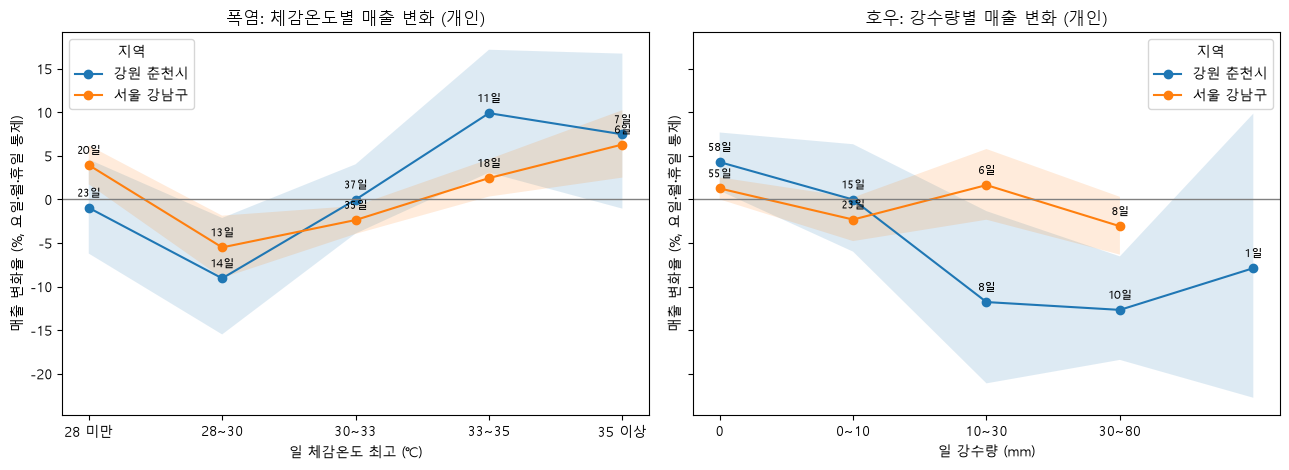

In [11]:
# ============================================================
# [순서 3 | A] 강도-반응 추세 그림
# 데이터: 07
# 목적: 체감온도·강수량이 세질수록 매출이 어떻게 변하는지 확인
#       → 꺾이는 지점이 있으면 H를 임계값(특보형)으로,
#         완만하게 변하면 연속값으로 정의하는 근거
# ============================================================
import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 법인 결제는 날씨보다 업무 일정 영향이 커서 기본은 '개인'으로 봄 ('개인+법인'으로 바꿔 비교 가능)
대상 = '개인'

df = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig',
                 dtype={'일자': str}, low_memory=False)
df['일자'] = pd.to_datetime(df['일자'], format='%Y%m%d')
df['결제금액'] = df['개인_결제금액'].fillna(0) if 대상 == '개인' else \
                 df['개인_결제금액'].fillna(0) + df['법인_결제금액'].fillna(0)

# ── 1. 지역 × 업종 × 일자 + 일 단위 기상 ──
업종일 = df.groupby(['시군구', '카드업종', '일자'])['결제금액'].sum().reset_index()
날씨 = (df.groupby(['시군구', '일자'])
          .agg(체감최고=('일_체감온도최고_계산', 'max'),
               일강수=('일_강수합_mm', 'max'),
               요일=('요일', 'first'), 휴일=('휴일', 'first'))
          .reset_index())
추세df = 업종일.merge(날씨, on=['시군구', '일자'], how='left')

# ── 2. 요일·월·휴일 효과를 걷어낸 잔차 (전체 기간으로 추정) ──
추세df['로그매출'] = np.log1p(추세df['결제금액'])
추세df['휴일여부'] = (추세df['휴일'] == 'Y').astype(int)
추세df['월'] = 추세df['일자'].dt.month
추세df['그룹_월'] = 추세df['시군구'] + '_' + 추세df['카드업종'] + '_' + 추세df['월'].astype(str)
추세df['그룹_요일'] = 추세df['시군구'] + '_' + 추세df['카드업종'] + '_' + 추세df['요일']

기본모형 = pf.feols('로그매출 ~ 휴일여부 | 그룹_월 + 그룹_요일', data=추세df)
추세df.loc[기본모형._data.index, '잔차'] = 기본모형.resid()

# ── 3. 강도 구간 (여름 7~9월만) ──
여름 = 추세df[추세df['월'].between(7, 9) & 추세df['잔차'].notna()].copy()
여름['체감구간'] = pd.cut(여름['체감최고'], bins=[-np.inf, 28, 30, 33, 35, np.inf],
                        labels=['28 미만', '28~30', '30~33', '33~35', '35 이상'])
여름['강수구간'] = pd.cut(여름['일강수'], bins=[-np.inf, 0, 10, 30, 80, np.inf],
                        labels=['0', '0~10', '10~30', '30~80', '80 이상'])

def 구간요약(data, 구간열):
    g = (data.groupby(['시군구', 구간열], observed=True)
             .agg(평균잔차=('잔차', 'mean'), 표준오차=('잔차', 'sem'),
                  일수=('일자', 'nunique'))
             .reset_index())
    g['변화율(%)'] = (np.exp(g['평균잔차']) - 1) * 100
    g['하한'] = (np.exp(g['평균잔차'] - 1.96 * g['표준오차']) - 1) * 100
    g['상한'] = (np.exp(g['평균잔차'] + 1.96 * g['표준오차']) - 1) * 100
    return g

# ── 4. 표 + 그림 ──
설정 = [('체감구간', f'폭염: 체감온도별 매출 변화 ({대상})', '일 체감온도 최고 (℃)'),
        ('강수구간', f'호우: 강수량별 매출 변화 ({대상})', '일 강수량 (mm)')]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (구간열, 제목, x라벨) in zip(axes, 설정):
    요약 = 구간요약(여름, 구간열)
    print(f'\n[{제목}]')
    print(요약[['시군구', 구간열, '일수', '변화율(%)', '하한', '상한']]
          .rename(columns={구간열: '구간'}).round(2).to_string(index=False))

    for 지역, g in 요약.groupby('시군구'):
        x = np.arange(len(g))
        ax.plot(x, g['변화율(%)'], marker='o', label=지역)
        ax.fill_between(x, g['하한'], g['상한'], alpha=0.15)
        for xi, (v, n) in enumerate(zip(g['변화율(%)'], g['일수'])):
            ax.annotate(f'{n}일', (xi, v), textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8)
        ax.set_xticks(x, g[구간열].astype(str))
    ax.axhline(0, color='gray', lw=1)
    ax.set_title(제목)
    ax.set_xlabel(x라벨)
    ax.set_ylabel('매출 변화율 (%, 요일·월·휴일 통제)')
    ax.legend(title='지역')
plt.tight_layout()
plt.show()


[강원 춘천시 · 비 안 온 날만 폭염 곡선]
   구간  일수  변화율(%)     하한    상한
28 미만  10   13.63   5.26 22.67
28~30   7   -6.29 -15.33  3.71
30~33  25    1.46  -3.52  6.69
33~35   9    8.43   0.72 16.73
35 이상   7    7.46  -1.06 16.72

[서울 강남구 · 비 안 온 날만 폭염 곡선]
   구간  일수  변화율(%)    하한    상한
28 미만  10    9.31  6.17 12.55
28~30   6   -3.76 -7.72  0.37
30~33  20   -3.25 -5.22 -1.25
33~35  14    1.60 -0.73  3.99
35 이상   5    9.84  5.49 14.37


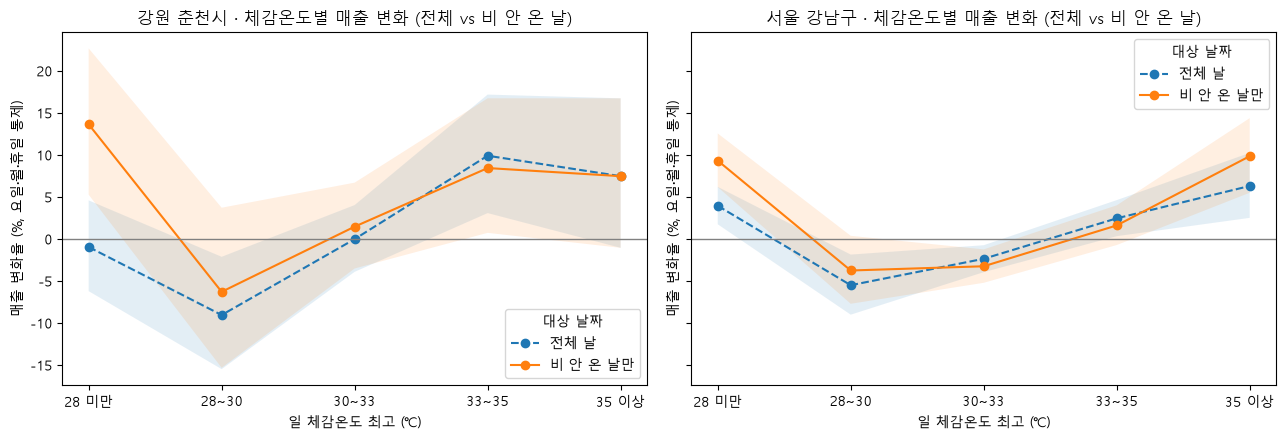


[강원 춘천시 · 폭염 · 구간별 일수] {'30 미만(기준)': np.int64(17), '30~33': np.int64(25), '33 이상': np.int64(16)}
폭염구간          30~33  33 이상
카드업종                      
세금공과금        -222.7 -147.8
쇼핑몰            56.0  -31.5
ZZ_나머지        -48.2  -21.8
보험              8.2  -13.2
할인점/슈퍼마켓/양판점   -1.6   -3.6
일반병원          -13.3   -2.7
한식             -1.8    0.2
기타요식           -1.5    0.5
컴퓨터/소프트웨어      14.7    1.2
커피전문점           1.1    3.7
의복/의류          -6.6    4.5
기타의료           38.1    5.7
종합병원           -5.7    6.1
학원/학습지          0.4    9.9

[서울 강남구 · 폭염 · 구간별 일수] {'30 미만(기준)': np.int64(16), '30~33': np.int64(20), '33 이상': np.int64(19)}
폭염구간          30~33  33 이상
카드업종                      
의복/의류         -13.1  -19.7
보험            -51.3  -19.6
기타요식          -17.3   -9.8
백화점            -5.0   -7.3
ZZ_나머지        -25.0   -3.6
일반병원           -6.0   -2.7
종합병원           -8.1   -2.4
할인점/슈퍼마켓/양판점   -4.1   -2.3
세금공과금         -39.0   -2.0
컴퓨터/소프트웨어       0.7   -1.7
한식             -4.0   -0.9
커피전문점          -3.6  

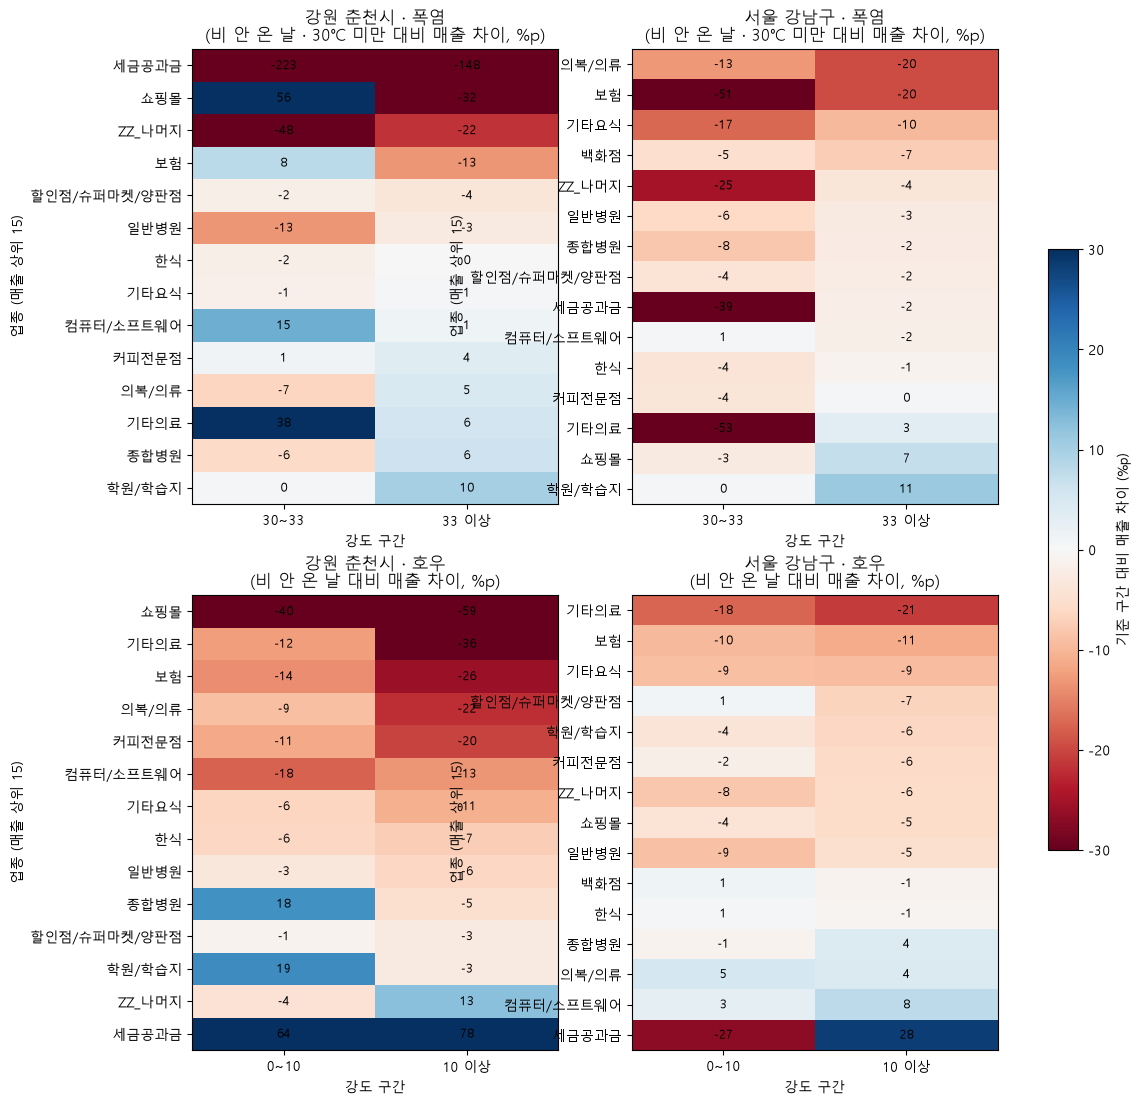

In [12]:
# ============================================================
# [순서 4 | 업종 × 강도 히트맵]
# 데이터: 07 (앞 셀 '강도-반응 추세 그림'의 여름 변수 사용)
# 목적: ① 비 온 날을 뺀 폭염 곡선으로 호우와 섞였는지 확인
#       ② 업종별로 폭염·호우 반응 방향이 엇갈리는지 확인 (S의 업종별 β 사전 점검)
# ============================================================

# ── ① 폭염 곡선 재확인: 전체 vs 비 안 온 날만 ──
무강수 = 여름[여름['일강수'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, 지역 in zip(axes, ['강원 춘천시', '서울 강남구']):
    for 데이터, 라벨, 선 in [(여름, '전체 날', '--'), (무강수, '비 안 온 날만', '-')]:
        요약 = 구간요약(데이터[데이터['시군구'] == 지역], '체감구간')
        x = np.arange(len(요약))
        ax.plot(x, 요약['변화율(%)'], marker='o', ls=선, label=라벨)
        ax.fill_between(x, 요약['하한'], 요약['상한'], alpha=0.12)
        ax.set_xticks(x, 요약['체감구간'].astype(str))
        if 라벨 == '비 안 온 날만':
            print(f'\n[{지역} · 비 안 온 날만 폭염 곡선]')
            print(요약[['체감구간', '일수', '변화율(%)', '하한', '상한']]
                  .rename(columns={'체감구간': '구간'}).round(2).to_string(index=False))
    ax.axhline(0, color='gray', lw=1)
    ax.set_title(f'{지역} · 체감온도별 매출 변화 (전체 vs 비 안 온 날)')
    ax.set_xlabel('일 체감온도 최고 (℃)')
    ax.set_ylabel('매출 변화율 (%, 요일·월·휴일 통제)')
    ax.legend(title='대상 날짜')
plt.tight_layout()
plt.show()

# ── ② 업종 × 강도 히트맵 (기준 구간 대비 차이) ──
# 폭염은 비 섞임을 막기 위해 '비 안 온 날'만 사용, 구간은 3개로 단순화
무강수 = 무강수.copy()
무강수['폭염구간'] = pd.cut(무강수['체감최고'], bins=[-np.inf, 30, 33, np.inf],
                          labels=['30 미만(기준)', '30~33', '33 이상'])
여름['호우구간'] = pd.cut(여름['일강수'], bins=[-np.inf, 0, 10, np.inf],
                        labels=['0(기준)', '0~10', '10 이상'])

상위업종 = 여름.groupby('카드업종')['결제금액'].sum().nlargest(15).index

def 업종표(data, 지역, 구간열):
    d = data[(data['시군구'] == 지역) & (data['카드업종'].isin(상위업종))]
    표 = d.groupby(['카드업종', 구간열], observed=True)['잔차'].mean().unstack()
    표 = (np.exp(표) - 1) * 100
    기준 = 표.columns[0]
    차이 = 표.drop(columns=기준).sub(표[기준], axis=0)       # 기준 구간 대비 %p 차이
    일수 = d.groupby(구간열, observed=True)['일자'].nunique()
    return 차이.sort_values(차이.columns[-1]), 일수

설정 = [('폭염', 무강수, '폭염구간', '비 안 온 날 · 30℃ 미만 대비'),
        ('호우', 여름, '호우구간', '비 안 온 날 대비')]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for i, (재해, 데이터, 구간열, 기준설명) in enumerate(설정):
    for j, 지역 in enumerate(['강원 춘천시', '서울 강남구']):
        차이, 일수 = 업종표(데이터, 지역, 구간열)
        print(f'\n[{지역} · {재해} · 구간별 일수]', dict(일수))
        print(차이.round(1).to_string())
        ax = axes[i, j]
        im = ax.imshow(차이.values, cmap='RdBu', vmin=-30, vmax=30, aspect='auto')
        ax.set_xticks(range(차이.shape[1]), 차이.columns.astype(str))
        ax.set_yticks(range(차이.shape[0]), 차이.index)
        for r in range(차이.shape[0]):
            for c in range(차이.shape[1]):
                v = 차이.values[r, c]
                if not np.isnan(v):
                    ax.text(c, r, f'{v:.0f}', ha='center', va='center', fontsize=9)
        ax.set_title(f'{지역} · {재해}\n({기준설명} 매출 차이, %p)')
        ax.set_xlabel('강도 구간')
        ax.set_ylabel('업종 (매출 상위 15)')
fig.colorbar(im, ax=axes, label='기준 구간 대비 매출 차이 (%p)', shrink=0.6)
plt.show()

In [14]:
# ============================================================
# [순서 5 | 카드업종 ↔ 상가업종 매핑]
# 데이터: 07 + 04 (+ 01 점포의 중분류 참고)
# 목적: 카드업종 91개와 상가업종 대분류 10개를 잇는 매핑표를 만들기 위한 목록 확인
#       → S = 업종별 β × 상권 업종 비중 계산의 전제 조건
# ============================================================
import pandas as pd

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

카드 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig', low_memory=False)
상권 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\04_상권_147곳_202506.csv', encoding='utf-8-sig')
점포 = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\01_점포_202506.csv', encoding='utf-8-sig', low_memory=False)

# ── 1. 카드업종 91개: 개인 결제금액 비중 (지역별) ──
카드업종표 = (카드.groupby(['카드업종', '시군구'])['개인_결제금액'].sum()
                .unstack('시군구').fillna(0))
카드업종표['합계'] = 카드업종표.sum(axis=1)
for c in ['강원 춘천시', '서울 강남구', '합계']:
    카드업종표[f'{c} 비중(%)'] = (카드업종표[c] / 카드업종표[c].sum() * 100).round(2)
카드업종표 = 카드업종표.sort_values('합계', ascending=False)
카드업종표['누적비중(%)'] = 카드업종표['합계 비중(%)'].cumsum().round(1)
카드업종표.index.name = '카드업종'

print(f'[카드업종 {len(카드업종표)}개 · 개인 결제금액 비중]')
print(카드업종표[['강원 춘천시 비중(%)', '서울 강남구 비중(%)', '합계 비중(%)', '누적비중(%)']].to_string())

# ── 2. 상가업종 대분류 (04 상권 파일 기준) ──
대분류 = [c.replace('업종_', '') for c in 상권.columns if c.startswith('업종_')]
print(f'\n[상가업종 대분류 {len(대분류)}개 (04 상권 파일)]')
print(대분류)

# ── 3. 상가업종 대분류 → 중분류 (01 점포, 매핑 판단 참고용) ──
중분류표 = (점포.groupby(['상권업종대분류명', '상권업종중분류명']).size()
              .rename('점포 수').reset_index()
              .sort_values(['상권업종대분류명', '점포 수'], ascending=[True, False]))
print(f'\n[상가업종 대분류 → 중분류 (점포 수)]')
print(중분류표.to_string(index=False))

[카드업종 91개 · 개인 결제금액 비중]
시군구              강원 춘천시 비중(%)  서울 강남구 비중(%)  합계 비중(%)  누적비중(%)
카드업종                                                          
세금공과금                    0.00         30.13     28.07     28.1
ZZ_나머지                  24.84         21.26     21.50     49.6
일반병원                     3.25          5.44      5.29     54.9
할인점/슈퍼마켓/양판점            11.87          3.88      4.43     59.3
컴퓨터/소프트웨어                0.05          4.60      4.29     63.6
보험                       0.01          3.72      3.46     67.0
쇼핑몰                      0.00          3.62      3.37     70.4
학원/학습지                   1.39          3.29      3.16     73.6
한식                      11.00          2.36      2.95     76.5
기타의료                     0.56          1.93      1.84     78.4
백화점                      0.00          1.88      1.75     80.1
기타요식                     4.35          1.44      1.64     81.8
종합병원                     1.80          1.45      1.47     83.2
의복/의류                    0.85  

In [15]:
# ============================================================
# [순서 5 | 카드업종 ↔ 상가업종 매핑 (2/2) - 매핑 적용·점검]
# 데이터: 07 + 04 (앞 셀의 카드업종표, 상권, 대분류 사용)
# 목적: ① 91개 카드업종이 빠짐없이 매핑됐는지 확인
#       ② 대분류별 카드 매출 비중 vs 점포 수 비중 비교 → S의 업종 구성 기준 결정
# ============================================================

매핑초안 = {
    '음식': ['한식', '일식', '양식', '중식', '기타요식', '패스트푸드', '커피전문점', '제과점', '유흥업소'],
    '소매': ['할인점/슈퍼마켓/양판점', '편의점', '백화점', '의복/의류', '패션잡화', '화장품', '약국',
             '기타식품', '정육점', '농수산물', '주류판매', '생활잡화/수입상품점', '시계/귀금속', '가전',
             '가구', '인테리어/건축자재/주방기구', '스포츠/레저용품', '서점', '문화용품',
             '사무기기/문구용품', '완구/아동용자전거', '악기/음반', '화원', '애완동물', '주유소',
             'LPG가스', '자동차용품', '오토바이', '기타유통', '중고품판매점', '수제용품점', '전용매장',
             '면세점', '체인점'],
    '보건의료': ['일반병원', '종합병원', '치과병원', '한의원', '기타의료', '보건소'],
    '수리·개인': ['미용실', '미용서비스', '세탁소', '자동차서비스', '싸우나/목욕탕', '안마/마사지',
                 '장례식장/묘지/장의사', '예식장/결혼서비스'],
    '숙박': ['호텔/콘도', '모텔,여관,기타숙박'],
    '예술·스포츠': ['헬스장', '스포츠시설', '실내/실외골프장', '게임방/오락실', '노래방', '영화/공연',
                  '종합레저타운/놀이동산', '독서실'],
    '교육': ['학원/학습지', '유치원'],
    '과학·기술': ['연구/번역서비스', '법률/사무서비스', '회계/변리서비스', '동물병원'],
    '부동산': ['부동산중개'],
    '시설관리·임대': ['여행사/항공사', '주차장'],
    '제외': ['세금공과금', 'ZZ_나머지', '보험', '컴퓨터/소프트웨어', '쇼핑몰', '상품권/복권',
            '통신요금(이동,시내전화)', '통신요금(PC통신,무선호출)', '결제대행(PG)',
            '방문판매/다단계판매', '학교등록금', '고속버스/철도/여객선', '택시', '수입자동차', '중고차판매'],
}
업종매핑 = {업종: 대분류 for 대분류, 목록 in 매핑초안.items() for 업종 in 목록}

# ── ① 매핑 누락·중복 점검 ──
전체업종 = set(카드업종표.index)
매핑업종 = [u for 목록 in 매핑초안.values() for u in 목록]
print('[매핑 점검]')
print('카드업종 수:', len(전체업종), '/ 매핑된 업종 수:', len(set(매핑업종)))
print('매핑 누락:', 전체업종 - set(매핑업종))
print('목록에 없는 이름(오타):', set(매핑업종) - 전체업종)
print('중복 매핑:', {u for u in 매핑업종 if 매핑업종.count(u) > 1})

# ── ② 대분류별 카드 매출 비중 (지역별, 개인 결제금액) ──
매출 = 카드업종표[['강원 춘천시', '서울 강남구']].copy()
매출['대분류'] = 매출.index.map(업종매핑)
대분류매출 = 매출.groupby('대분류')[['강원 춘천시', '서울 강남구']].sum()

print('\n[제외 업종이 차지하는 개인 매출 비중]')
print((대분류매출.loc['제외'] / 대분류매출.sum() * 100).round(1).rename('제외 비중(%)'))

# 제외를 뺀 나머지 안에서의 비중
대상매출 = 대분류매출.drop(index='제외')
카드비중 = (대상매출 / 대상매출.sum() * 100)

# ── ③ 대분류별 점포 수 비중 (04 상권 파일, 지역별 합계) ──
점포수 = 상권.groupby('시군구')[[f'업종_{d}' for d in 대분류]].sum().T
점포수.index = [i.replace('업종_', '') for i in 점포수.index]
점포비중 = 점포수 / 점포수.sum() * 100

# ── ④ 비교표 ──
비교 = pd.concat({'카드매출 비중(%)': 카드비중, '점포수 비중(%)': 점포비중}, axis=1).round(1)
비교 = 비교.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
비교.index.name = '상가 대분류'
print('\n[대분류별 카드 매출 비중 vs 점포 수 비중 (제외 업종 뺀 기준)]')
print(비교.to_string())

# 팀이 매핑을 확정한 뒤 공유용 저장이 필요할 때만 주석 해제
# pd.Series(업종매핑, name='상가대분류').rename_axis('카드업종').to_csv('카드업종_상가대분류_매핑.csv', encoding='utf-8-sig')

[매핑 점검]
카드업종 수: 91 / 매핑된 업종 수: 91
매핑 누락: set()
목록에 없는 이름(오타): set()
중복 매핑: set()

[제외 업종이 차지하는 개인 매출 비중]
시군구
강원 춘천시    25.4
서울 강남구    65.0
Name: 제외 비중(%), dtype: float64

[대분류별 카드 매출 비중 vs 점포 수 비중 (제외 업종 뺀 기준)]
시군구        강원 춘천시               서울 강남구           
        점포수 비중(%) 카드매출 비중(%) 점포수 비중(%) 카드매출 비중(%)
상가 대분류                                           
과학·기술         6.9        0.6      30.6        1.1
교육            7.2        2.8       9.6        9.6
보건의료          2.6       10.0       4.7       28.1
부동산           2.6        0.0       5.8        0.0
소매           22.8       49.7      14.9       34.3
수리·개인        11.9        4.0       7.1        4.2
숙박            3.4        0.6       0.8        1.0
시설관리·임대       3.6        0.0       5.1        0.3
예술·스포츠        4.9        5.4       2.7        1.8
음식           34.2       26.9      18.8       19.7



[강원 춘천시 · 폭염 · 시간대별 매출 차이 (비 안 온 날 · 30℃ 미만 대비)]
  시간대    구간  일수  차이(%p)  95% 오차범위(±)
00_05 30~33  25    3.34        10.22
00_05 33 이상  16   -2.46         9.20
06_11 30~33  25   -2.91         4.28
06_11 33 이상  16    1.18         4.67
12_17 30~33  25   -2.43         5.25
12_17 33 이상  16   -2.19         5.61
18_23 30~33  25   -2.23         4.02
18_23 33 이상  16   -0.70         5.02

[서울 강남구 · 폭염 · 시간대별 매출 차이 (비 안 온 날 · 30℃ 미만 대비)]
  시간대    구간  일수  차이(%p)  95% 오차범위(±)
00_05 30~33  20   -1.04         7.48
00_05 33 이상  19    3.28         5.94
06_11 30~33  20   -9.95         8.38
06_11 33 이상  19   -2.26         8.37
12_17 30~33  20   -8.28         8.33
12_17 33 이상  19   -1.15         8.62
18_23 30~33  20   -1.80         5.75
18_23 33 이상  19    0.78         5.49

[강원 춘천시 · 호우 · 시간대별 매출 차이 (비 안 온 날 대비)]
  시간대    구간  일수  차이(%p)  95% 오차범위(±)
00_05  0~10  15   -5.31         7.60
00_05 10 이상  19   -9.49         8.21
06_11  0~10  15   -0.40         3.62
06_11 10 이상  19  -10.80         4.79
12_17  0

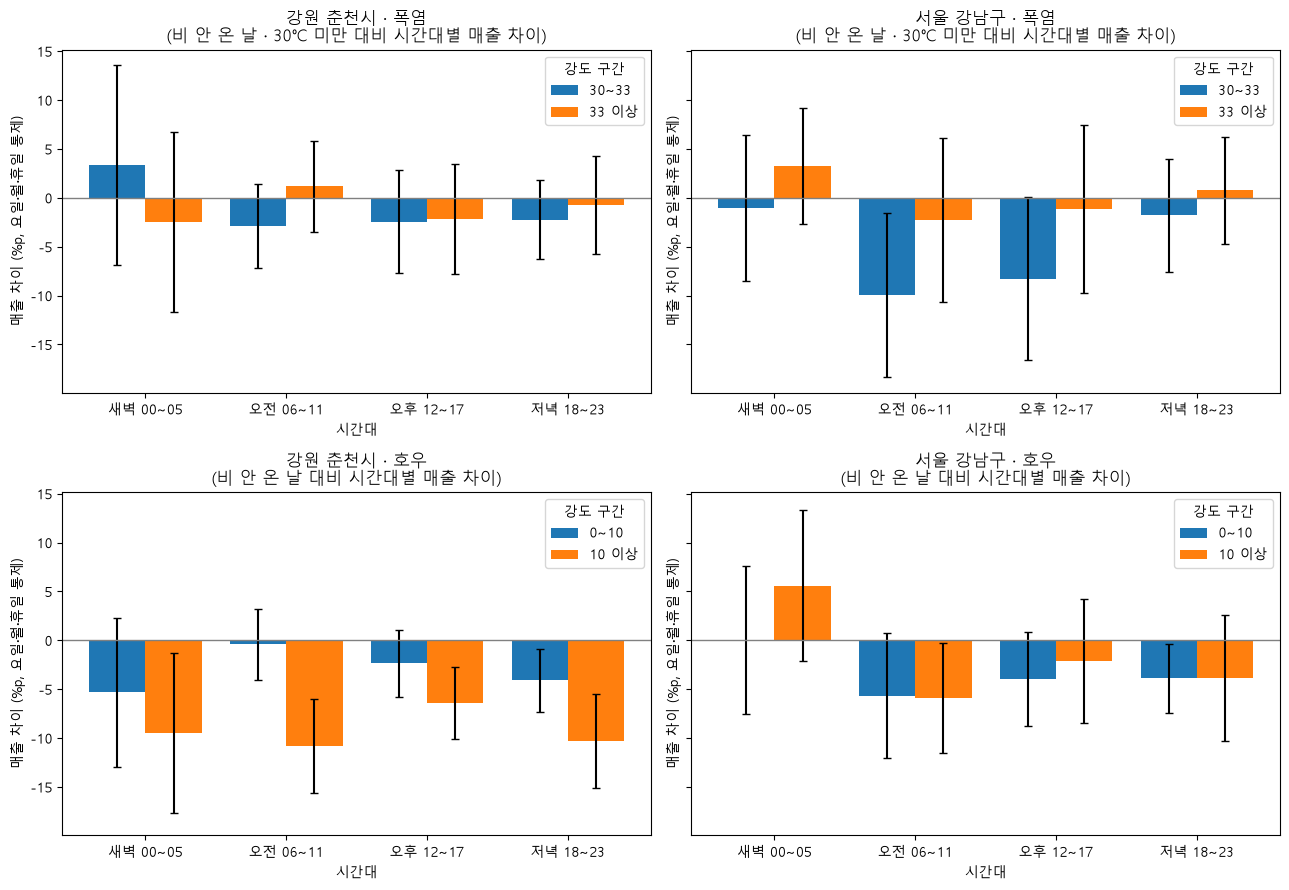

In [16]:
# ============================================================
# [선택 | 시간대별 반응]
# 데이터: 07 (앞 셀 '카드업종 ↔ 상가업종 매핑'의 카드, 업종매핑 사용)
# 목적: 폭염·호우 때 매출이 줄어드는지, 아니면 시간대가 이동하는지 확인
#       → 액션플랜(시간대 대응)과 E(야외노출도) 설계 근거
# ============================================================
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 1. 소비자 대면 업종만, 지역 × 일자 × 시간대 개인 매출 ──
비대면 = ['제외', '과학·기술', '부동산', '시설관리·임대']
시간df = 카드.copy()
시간df['대분류'] = 시간df['카드업종'].map(업종매핑)
시간df = 시간df[~시간df['대분류'].isin(비대면)]
시간df['일자'] = pd.to_datetime(시간df['일자'].astype(str), format='%Y%m%d')

시간일 = (시간df.groupby(['시군구', '일자', '시간대'])
            .agg(결제금액=('개인_결제금액', 'sum'),
                 체감최고=('일_체감온도최고_계산', 'max'),
                 일강수=('일_강수합_mm', 'max'),
                 요일=('요일', 'first'), 휴일=('휴일', 'first'))
            .reset_index())

# ── 2. 요일·월·휴일 효과 제거 (지역 × 시간대별로 따로) ──
시간일['로그매출'] = np.log(시간일['결제금액'])
시간일['휴일여부'] = (시간일['휴일'] == 'Y').astype(int)
시간일['월'] = 시간일['일자'].dt.month
시간일['그룹_월'] = 시간일['시군구'] + '_' + 시간일['시간대'] + '_' + 시간일['월'].astype(str)
시간일['그룹_요일'] = 시간일['시군구'] + '_' + 시간일['시간대'] + '_' + 시간일['요일']

모형 = pf.feols('로그매출 ~ 휴일여부 | 그룹_월 + 그룹_요일', data=시간일)
시간일.loc[모형._data.index, '잔차'] = 모형.resid()

# ── 3. 여름, 강도 구간 (폭염은 비 안 온 날만) ──
여름시간 = 시간일[시간일['월'].between(7, 9) & 시간일['잔차'].notna()].copy()
여름시간['폭염구간'] = pd.cut(여름시간['체감최고'], bins=[-np.inf, 30, 33, np.inf],
                            labels=['30 미만(기준)', '30~33', '33 이상'])
여름시간.loc[여름시간['일강수'] > 0, '폭염구간'] = np.nan
여름시간['호우구간'] = pd.cut(여름시간['일강수'], bins=[-np.inf, 0, 10, np.inf],
                            labels=['0(기준)', '0~10', '10 이상'])

def 시간대차이(data, 지역, 구간열):
    d = data[data['시군구'] == 지역].dropna(subset=[구간열])
    g = d.groupby(['시간대', 구간열], observed=True)['잔차'].agg(['mean', 'sem', 'count']).reset_index()
    기준명 = d[구간열].cat.categories[0]
    기준 = g[g[구간열] == 기준명].set_index('시간대')
    g = g[g[구간열] != 기준명].copy()
    g['차이(%p)'] = (g['mean'] - g['시간대'].map(기준['mean'])) * 100
    g['오차'] = 1.96 * np.sqrt(g['sem'] ** 2 + g['시간대'].map(기준['sem']) ** 2) * 100
    g['일수'] = g['count']
    return g

# ── 4. 표 + 그림 ──
설정 = [('폭염', '폭염구간', '비 안 온 날 · 30℃ 미만 대비'), ('호우', '호우구간', '비 안 온 날 대비')]
시간순 = ['00_05', '06_11', '12_17', '18_23']

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for i, (재해, 구간열, 기준설명) in enumerate(설정):
    for j, 지역 in enumerate(['강원 춘천시', '서울 강남구']):
        g = 시간대차이(여름시간, 지역, 구간열)
        print(f'\n[{지역} · {재해} · 시간대별 매출 차이 ({기준설명})]')
        print(g[['시간대', 구간열, '일수', '차이(%p)', '오차']]
              .rename(columns={구간열: '구간', '오차': '95% 오차범위(±)'}).round(2).to_string(index=False))
        ax = axes[i, j]
        구간목록 = g[구간열].unique()
        폭 = 0.8 / len(구간목록)
        for k, 구간 in enumerate(구간목록):
            s = g[g[구간열] == 구간].set_index('시간대').reindex(시간순)
            x = np.arange(len(시간순)) + (k - (len(구간목록) - 1) / 2) * 폭
            ax.bar(x, s['차이(%p)'], width=폭, yerr=s['오차'], capsize=3, label=str(구간))
        ax.axhline(0, color='gray', lw=1)
        ax.set_xticks(np.arange(len(시간순)), ['새벽 00~05', '오전 06~11', '오후 12~17', '저녁 18~23'])
        ax.set_title(f'{지역} · {재해}\n({기준설명} 시간대별 매출 차이)')
        ax.set_xlabel('시간대')
        ax.set_ylabel('매출 차이 (%p, 요일·월·휴일 통제)')
        ax.legend(title='강도 구간')
plt.tight_layout()
plt.show()